# Q2 — Which restaurants disagree the most? (pairwise)

Because the pairs rest on very different sample sizes, the biggest disagreers are listed
**per pair** (Google vs Tripadvisor, Google vs TheFork) and for the all-three set, rather
than pooled. This reproduces and extends the README's mandatory *"rating difference > 1
star"* query.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
q2_gta = publish(run(queries.q2_top_pair("google", "tripadvisor", top_n=20, min_diff=1.0)),
                 "q2_top_google_vs_tripadvisor",
                 "Q2 — Largest Google vs Tripadvisor rating gaps (>1 star).")
q2_gta

,canonical_name,canonical_city,google_rating,tripadvisor_rating,abs_diff,google_reviews,tripadvisor_reviews
0,SUSHI NIKKEI Duomo San Babila Milano - Restaur...,Milano,4.7,1.0,3.7,87,1
1,Villa,Milano,4.6,1.0,3.6,70,1
2,Osteria San Giovanni - Ristorante Pugliese,Milano,4.6,1.0,3.6,101,1
3,Silia Pizza al Trancio,Milano,4.5,1.0,3.5,274,1
4,Poke House - Nirone,Milano,4.5,1.0,3.5,329,2
5,Il Buon Pane,Milano,4.5,1.0,3.5,80,1
6,Pizzeria S. Stefano,Milano,4.5,1.0,3.5,152,1
7,Vino,Milano,4.4,1.0,3.4,314,2
8,Vibes cocktail bar,Milano,4.4,1.0,3.4,258,2
9,Cento Caffè caffetteria,Milano,4.4,1.0,3.4,511,1


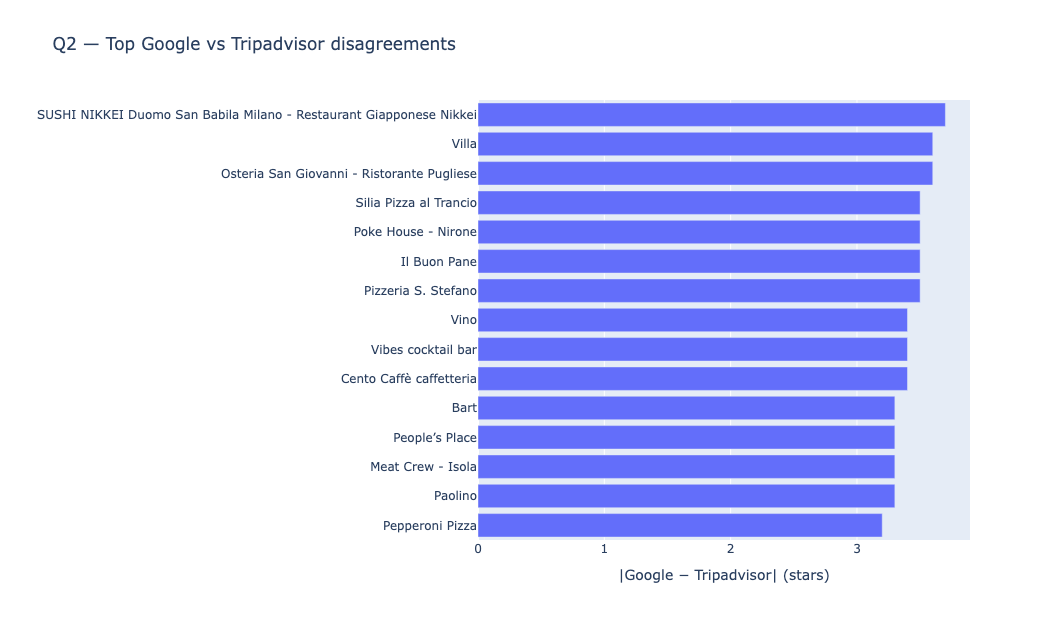

In [3]:
if not q2_gta.empty:
    top = q2_gta.head(15)[::-1]
    fig = px.bar(top, x="abs_diff", y="canonical_name", orientation="h",
                 hover_data=["canonical_city", "google_rating", "tripadvisor_rating"],
                 labels={"abs_diff": "|Google − Tripadvisor| (stars)", "canonical_name": ""},
                 title="Q2 — Top Google vs Tripadvisor disagreements")
    fig.show()

In [4]:
q2_gtf = publish(run(queries.q2_top_pair("google", "thefork", top_n=20, min_diff=1.0)),
                 "q2_top_google_vs_thefork",
                 "Q2 — Largest Google vs TheFork rating gaps (>1 star).")
q2_gtf

,canonical_name,canonical_city,google_rating,thefork_rating,abs_diff,google_reviews,thefork_reviews
0,Tasty Bite Cucina Indiana,Milano,4.8,1.00,3.80,37,<NA>
1,Mia Poke,Milano,4.4,1.65,2.75,43,3
2,Archie’s - Comida Peruviana,Milano,4.4,2.15,2.25,204,5
3,Il francolino Pizzeria / Bar,Milano,4.5,3.00,1.50,10,<NA>
4,Solar Grill,Milano,2.9,4.20,1.30,19,118
5,Spadari Restaurant,Milano,2.8,3.90,1.10,815,6
6,Benza,Milano,3.9,2.85,1.05,203,191


In [5]:
q2_all = publish(run(queries.q2_top_all_three(top_n=20)), "q2_top_all_three",
                 "Q2 — Largest full-range disagreements among all-three-platform venues.")
q2_all

,canonical_name,canonical_city,google_rating_5,tripadvisor_rating_5,thefork_rating_5,rating_range_5
0,Ristorante Pesce D'amare,Milano,4.3,2.0,4.35,2.35
1,Pizza Garage,Milano,4.1,2.1,4.40,2.30
2,SANCEN RISTORANTE CINESE (SHANCHENG) 山城小灶,Milano,4.8,3.1,5.00,1.90
3,Salotto Brera,Milano,4.4,2.5,4.15,1.90
4,Osteria delle Coppelle Milano,Milano,3.5,2.4,4.20,1.80
5,Sandì,Milano,4.7,3.0,4.65,1.70
6,Trattoria dell'Arco,Milano,4.7,3.0,4.35,1.70
7,Gòodurie Soresina,Milano,4.3,2.6,4.25,1.70
8,Ci Sta - Buenos Aires,Milano,4.3,2.8,4.40,1.60
9,La Jungle De Plein - Bistrot & Garden,Milano,4.6,3.0,4.00,1.60


**Answer (Q2):** The worst disagreements are dominated by the Google–Tripadvisor pair
(largest sample, widest gaps). `q2_top_google_vs_thefork` is much shorter — few venues are
on both Google and TheFork *and* disagree by >1 star, consistent with Q1's finding that
those two platforms largely agree. The per-platform columns show which source is the
outlier in each case.